In [2]:
import os

curr_dir = '/home/eboix/projects/secret_moe' ## Directory where the code is
scratch_dir = '/scratch/tmp/eboix/' ## Directory where activations are saved
os.chdir(curr_dir)

import pickle

class hashabledict(dict):
    def __key(self):
        return tuple((k,self[k]) for k in sorted(self))

    def __hash__(self):
        return hash(self.__key())

    def __eq__(self, other):
        return self.__key() == other.__key()

distill_scores = {}
incomplete_jobs = set()
generate_srun = False



# Load MLP distillation accuracies

In [3]:
# Distill to MLP
for model_name, layer_idx in [('EleutherAI/pythia-70m', 3), ('google/gemma-3-270m', 9), ('EleutherAI/pythia-410m', 12)]: # 
    for batch_size, num_epochs in [(1024, 100)]:
        for learning_rate in (3e-4, 1e-4, 1e-3):
            for hidden_dim in [2**4, 2**5, 2**6,2**7,2**8,2**9,2**10,2**11,2**12,2**13]:
                activ_dir = os.path.join(scratch_dir, f'saved_activations/wikitext_wikitext-2-raw-v1_{model_name.replace("/","_")}_layer{layer_idx}_actinput_train_mintok20')
                output_folder = os.path.join(curr_dir, f'saved_logs/mlp_distillation/{model_name.replace("/","_")}_layer{layer_idx}_hidden{hidden_dim}_bs{batch_size}_epochs{num_epochs}_lr{learning_rate}')
                # srun command generation
                srun_command = f"srun python distill_teacher_to_mlp_student.py --activ_dir {activ_dir} --layer_idx {layer_idx} --model_name {model_name} --batch_size {batch_size} --num_epochs {num_epochs} --learning_rate {learning_rate} --hidden_dim {hidden_dim} --output_folder {output_folder}"
                if generate_srun:
                    print(srun_command)
                else:
                    output_log_file = os.path.join(output_folder, 'output_logs.pkl')
                    if not os.path.exists(output_log_file):
                        # print(f"Log not found for {output_folder}")
                        print(srun_command)
                        # raise ValueError(f"Log not found for {output_folder}. Please run the command: {srun_command}")
                    else:
                        with open(output_log_file, 'rb') as f:
                            logs = pickle.load(f)
                        distill_scores[(model_name, layer_idx, 'distillToMLP', batch_size, num_epochs, learning_rate, hidden_dim)] = logs

In [4]:
# Distill to MLP (Gaussian)

generate_srun = False
for model_name, layer_idx in [('EleutherAI/pythia-70m', 3),  ('google/gemma-3-270m', 9), ('EleutherAI/pythia-410m', 12)]: #
    for batch_size, num_epochs in [(1024, 100)]:
        for learning_rate in (3e-4, 1e-4, 1e-3):
            for hidden_dim in [2**4, 2**5, 2**6,2**7,2**8,2**9,2**10, 2**11, 2**12, 2**13]: # ,2**12,2**13,2**14
                activ_dir = os.path.join(scratch_dir, f'gaussian_datasets/wikitext_wikitext-2-raw-v1_{model_name.replace("/","_")}_layer{layer_idx}_actinput_train_mintok20_gaussian')
                output_folder = os.path.join(curr_dir, f'saved_logs/mlp_distillation/{model_name.replace("/","_")}_gaussian_layer{layer_idx}_hidden{hidden_dim}_bs{batch_size}_epochs{num_epochs}_lr{learning_rate}')
                # srun command generation
                srun_command = f"srun python distill_teacher_to_mlp_student.py --activ_dir {activ_dir} --layer_idx {layer_idx} --model_name {model_name} --batch_size {batch_size} --num_epochs {num_epochs} --learning_rate {learning_rate} --hidden_dim {hidden_dim} --output_folder {output_folder}"
                if generate_srun:
                    print(srun_command)
                    os.system(srun_command.replace('srun ', ''))
                else:
                    output_log_file = os.path.join(output_folder, 'output_logs.pkl')
                    if not os.path.exists(output_log_file):
                        print(srun_command)
                        # os.system(srun_command.replace('srun ', ''))
                        continue
                        print(f"Log not found for {output_folder}")
                        raise ValueError(f"Log not found for {output_folder}. Please run the command: {srun_command}")
                    else:
                        with open(output_log_file, 'rb') as f:
                            logs = pickle.load(f)
                        distill_scores[(model_name + '_gaussian', layer_idx, 'distillToMLP', batch_size, num_epochs, learning_rate, hidden_dim)] = logs

# Load Shared+MoE with (low-rank router) distillation accuracies

In [8]:
# Distill to MLP plus MoE, single neuron experts embedding efficient, key proj

generate_srun = False
for model_name, layer_idx in [('google/gemma-3-270m', 9), ('EleutherAI/pythia-70m', 3), ('EleutherAI/pythia-410m', 12)]:
    for batch_size, num_epochs in [(1024, 100)]:
        for learning_rate in (3e-4, 1e-4, 1e-3):
            for num_experts in [1_000, 10_000, 100000]:
                pkd_dict = {'google/gemma-3-270m' : 128,
                            'EleutherAI/pythia-70m' : 128,
                            'EleutherAI/pythia-410m' : 256}
                
                key_proj_dim = pkd_dict[model_name]
                for shared_hidden_dim, granularity, expert_hidden_dim in [
                                                                            (8,8,1),
                                                                            (16,16,1),
                                                                            (32, 32, 1),
                                                                            (64, 64, 1),
                                                                            (128, 128, 1),
                                                                            (256,256,1),
                                                                            (512,512,1),
                                                                            (1024,1024,1),
                                                                                        ]: # up to 500000 experts fit on one L40S for dim 128   
                    if granularity > num_experts:
                        continue
                    activ_dir = os.path.join(scratch_dir, f'saved_activations/wikitext_wikitext-2-raw-v1_{model_name.replace("/","_")}_layer{layer_idx}_actinput_train_mintok20')
                    output_folder = os.path.join(curr_dir, f'saved_logs/mlp_plus_moe_distillation_snprojembd/{model_name.replace("/","_")}_layer{layer_idx}_shd{shared_hidden_dim}_{num_experts}e{granularity}a_ehd{expert_hidden_dim}_bs{batch_size}_epochs{num_epochs}_lr{learning_rate}')
                    # srun command generation
                    srun_command = f"srun python distill_teacher_to_mlp_plus_moesn_projembd.py --activ_dir {activ_dir} --layer_idx {layer_idx} --model_name {model_name} --batch_size {batch_size} --num_epochs {num_epochs} --learning_rate {learning_rate} --shared_hidden_dim {shared_hidden_dim} --num_experts {num_experts} --granularity {granularity} --expert_hidden_dim {expert_hidden_dim} --key_proj_dim {key_proj_dim} --output_folder {output_folder}"
                    if generate_srun:
                        print(srun_command)
                    else:
                        output_log_file = os.path.join(output_folder, 'output_logs.pkl')
                        if not os.path.exists(output_log_file):
                            # print(f"Log not found for {output_folder}")
                            print(srun_command)
                            incomplete_jobs.add(srun_command)
                            # raise ValueError(f"Log not found for {output_folder}. Please run the command: {srun_command}")
                        else:
                            with open(output_log_file, 'rb') as f:
                                logs = pickle.load(f)
                            hyperparam_tuple = hashabledict({
                                'batch_size': batch_size,
                                'num_epochs': num_epochs,
                                'learning_rate': learning_rate,
                                'shared_hidden_dim': shared_hidden_dim,
                                'granularity': granularity,
                                'num_experts': num_experts,
                                'expert_hidden_dim': expert_hidden_dim,
                                'key_proj_dim' : key_proj_dim
                            })
                            # print('Loaded logs for', output_folder)
                            distill_scores[(model_name, layer_idx, 'distillToMLPplusMoEsn_projembd', hyperparam_tuple)] = logs

In [10]:
# Distill to MLP plus MoE, single neuron experts embedding efficient, key proj
# Gaussian data

generate_srun = False
for model_name, layer_idx in [('google/gemma-3-270m', 9), ('EleutherAI/pythia-70m', 3), ('EleutherAI/pythia-410m', 12)]:
    for batch_size, num_epochs in [(1024, 100)]:
        for learning_rate in (3e-4, 1e-4, 1e-3):
            for num_experts in [1000, 10_000, 100000]:
                pkd_dict = {'google/gemma-3-270m' : 128,
                            'EleutherAI/pythia-70m' : 128,
                            'EleutherAI/pythia-410m' : 256}
                
                key_proj_dim = pkd_dict[model_name]
                for shared_hidden_dim, granularity, expert_hidden_dim in [
                                                                            (8,8,1),
                                                                            (16,16,1),
                                                                            (32, 32, 1),
                                                                            (64, 64, 1),
                                                                            (128, 128, 1),
                                                                            (256,256,1),
                                                                            (512,512,1),
                                                                            (1024,1024,1),
                                                                                        ]: # up to 500000 experts fit on one L40S for dim 128   
                    if granularity > num_experts:
                        continue
                    activ_dir = os.path.join(scratch_dir, f'gaussian_datasets/wikitext_wikitext-2-raw-v1_{model_name.replace("/","_")}_layer{layer_idx}_actinput_train_mintok20_gaussian')
                    output_folder = os.path.join(curr_dir, f'saved_logs/mlp_plus_moe_distillation_snprojembd/{model_name.replace("/","_")}_gaussian_layer{layer_idx}_shd{shared_hidden_dim}_{num_experts}e{granularity}a_ehd{expert_hidden_dim}_bs{batch_size}_epochs{num_epochs}_lr{learning_rate}')
                    # srun command generation
                    srun_command = f"srun python distill_teacher_to_mlp_plus_moesn_projembd.py --activ_dir {activ_dir} --layer_idx {layer_idx} --model_name {model_name} --batch_size {batch_size} --num_epochs {num_epochs} --learning_rate {learning_rate} --shared_hidden_dim {shared_hidden_dim} --num_experts {num_experts} --granularity {granularity} --expert_hidden_dim {expert_hidden_dim} --key_proj_dim {key_proj_dim} --output_folder {output_folder}"
                    if generate_srun:
                        print(srun_command)
                    else:
                        output_log_file = os.path.join(output_folder, 'output_logs.pkl')
                        if not os.path.exists(output_log_file):
                            # print(f"Log not found for {output_folder}")
                            print(srun_command)
                            incomplete_jobs.add(srun_command)
                            # raise ValueError(f"Log not found for {output_folder}. Please run the command: {srun_command}")
                        else:
                            with open(output_log_file, 'rb') as f:
                                logs = pickle.load(f)
                            hyperparam_tuple = hashabledict({
                                'batch_size': batch_size,
                                'num_epochs': num_epochs,
                                'learning_rate': learning_rate,
                                'shared_hidden_dim': shared_hidden_dim,
                                'granularity': granularity,
                                'num_experts': num_experts,
                                'expert_hidden_dim': expert_hidden_dim,
                                'key_proj_dim' : key_proj_dim
                            })
                            # print('Loaded logs for', output_folder)
                            distill_scores[(model_name + '_gaussian', layer_idx, 'distillToMLPplusMoEsn_projembd', hyperparam_tuple)] = logs

# Load Shared+MoE (full-rank router) distillation accuracies

In [12]:
# Distill to MLP plus MoE, single neuron experts embedding efficient, key proj

generate_srun = False
for model_name, layer_idx in [('google/gemma-3-270m', 9), ('EleutherAI/pythia-70m', 3), ('EleutherAI/pythia-410m', 12)]:
    for batch_size, num_epochs in [(1024, 100)]:
        for learning_rate in (3e-4, 1e-4, 1e-3):
            for num_experts in [10000, 100000]:
                
                for shared_hidden_dim, granularity, expert_hidden_dim in [
                                                                            (8,8,1),
                                                                            (16,16,1),
                                                                            (32, 32, 1),
                                                                            (64, 64, 1),
                                                                            (128, 128, 1),
                                                                            (256,256,1),
                                                                            (512,512,1),
                                                                            (1024,1024,1),
                                                                                        ]: # up to 500000 experts fit on one L40S for dim 128   
                    
                    activ_dir = os.path.join(scratch_dir, f'saved_activations/wikitext_wikitext-2-raw-v1_{model_name.replace("/","_")}_layer{layer_idx}_actinput_train_mintok20')
                    output_folder = os.path.join(curr_dir, f'saved_logs/mlp_plus_moe_distillation_singleneuron/{model_name.replace("/","_")}_layer{layer_idx}_shd{shared_hidden_dim}_{num_experts}e{granularity}a_ehd{expert_hidden_dim}_bs{batch_size}_epochs{num_epochs}_lr{learning_rate}')
                    # srun command generation
                    srun_command = f"srun python distill_teacher_to_mlp_plus_moes_student_singleneuron.py --activ_dir {activ_dir} --layer_idx {layer_idx} --model_name {model_name} --batch_size {batch_size} --num_epochs {num_epochs} --learning_rate {learning_rate} --shared_hidden_dim {shared_hidden_dim} --num_experts {num_experts} --granularity {granularity} --expert_hidden_dim {expert_hidden_dim} --output_folder {output_folder}"
                    if num_experts < granularity:
                        continue
                    if generate_srun:
                        print(srun_command)
                    else:
                        output_log_file = os.path.join(output_folder, 'output_logs.pkl')
                        if not os.path.exists(output_log_file):
                            # print(f"Log not found for {output_folder}")
                            print(srun_command)
                            incomplete_jobs.add(srun_command)
                            # raise ValueError(f"Log not found for {output_folder}. Please run the command: {srun_command}")
                        else:
                            with open(output_log_file, 'rb') as f:
                                logs = pickle.load(f)
                            hyperparam_tuple = hashabledict({
                                'batch_size': batch_size,
                                'num_epochs': num_epochs,
                                'learning_rate': learning_rate,
                                'shared_hidden_dim': shared_hidden_dim,
                                'granularity': granularity,
                                'num_experts': num_experts,
                                'expert_hidden_dim': expert_hidden_dim,
                            })
                            distill_scores[(model_name, layer_idx, 'distillToMLPplusMoE_singleneuron', hyperparam_tuple)] = logs

In [13]:
# Distill to MLP plus MoE, single neuron experts embedding efficient, key proj
# Gaussian data

generate_srun = False
for model_name, layer_idx in [('google/gemma-3-270m', 9), ('EleutherAI/pythia-70m', 3), ('EleutherAI/pythia-410m', 12)]:
    for batch_size, num_epochs in [(1024, 100)]:
        for learning_rate in (3e-4, 1e-4, 1e-3):
            for num_experts in [10_000, 100000]:
                for shared_hidden_dim, granularity, expert_hidden_dim in [
                                                                            (8,8,1),
                                                                            (16,16,1),
                                                                            (32, 32, 1),
                                                                            (64, 64, 1),
                                                                            (128, 128, 1),
                                                                            (256,256,1),
                                                                            (512,512,1),
                                                                            (1024,1024,1),
                                                                                        ]: # up to 500000 experts fit on one L40S for dim 128   
                    activ_dir = os.path.join(scratch_dir, f'gaussian_datasets/wikitext_wikitext-2-raw-v1_{model_name.replace("/","_")}_layer{layer_idx}_actinput_train_mintok20_gaussian')
                    output_folder = os.path.join(curr_dir, f'saved_logs/mlp_plus_moe_distillation_singleneuron/{model_name.replace("/","_")}_gaussian_layer{layer_idx}_shd{shared_hidden_dim}_{num_experts}e{granularity}a_ehd{expert_hidden_dim}_bs{batch_size}_epochs{num_epochs}_lr{learning_rate}')
                    # srun command generation
                    srun_command = f"srun python distill_teacher_to_mlp_plus_moe_singleneuron.py --activ_dir {activ_dir} --layer_idx {layer_idx} --model_name {model_name} --batch_size {batch_size} --num_epochs {num_epochs} --learning_rate {learning_rate} --shared_hidden_dim {shared_hidden_dim} --num_experts {num_experts} --granularity {granularity} --expert_hidden_dim {expert_hidden_dim} --output_folder {output_folder}"
                    if num_experts < granularity:
                        continue
                    if generate_srun:
                        print(srun_command)
                    else:
                        output_log_file = os.path.join(output_folder, 'output_logs.pkl')
                        if not os.path.exists(output_log_file):
                            # print(f"Log not found for {output_folder}")
                            print(srun_command)
                            incomplete_jobs.add(srun_command)
                            # raise ValueError(f"Log not found for {output_folder}. Please run the command: {srun_command}")
                        else:
                            with open(output_log_file, 'rb') as f:
                                logs = pickle.load(f)
                            hyperparam_tuple = hashabledict({
                                'batch_size': batch_size,
                                'num_epochs': num_epochs,
                                'learning_rate': learning_rate,
                                'shared_hidden_dim': shared_hidden_dim,
                                'granularity': granularity,
                                'num_experts': num_experts,
                                'expert_hidden_dim': expert_hidden_dim,
                            })
                            # print('Loaded logs for', output_folder)
                            distill_scores[(model_name + '_gaussian', layer_idx, 'distillToMLPplusMoE_singleneuron', hyperparam_tuple)] = logs

# Plot distillation accuracies

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

## MLP vs. MoE with proj

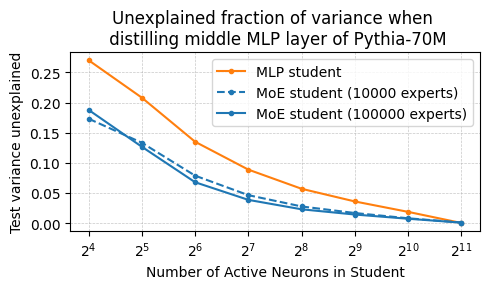

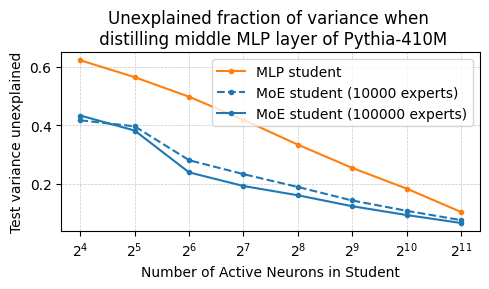

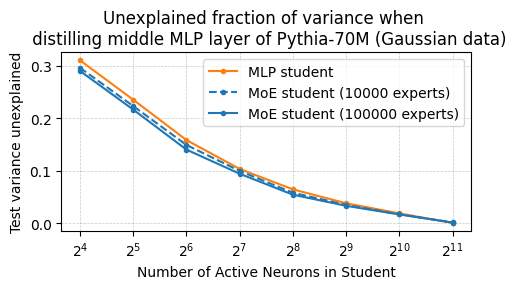

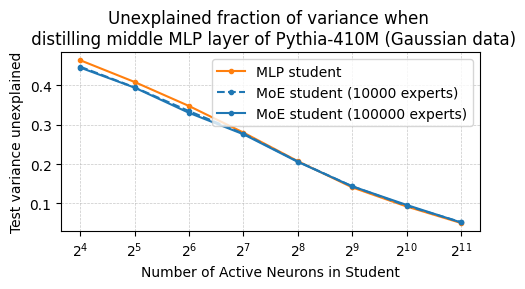

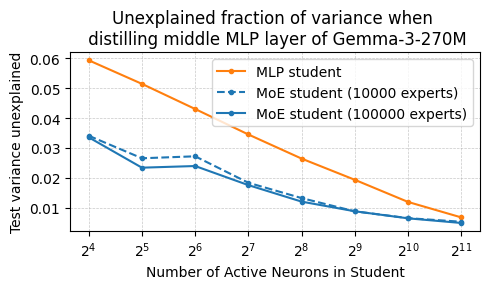

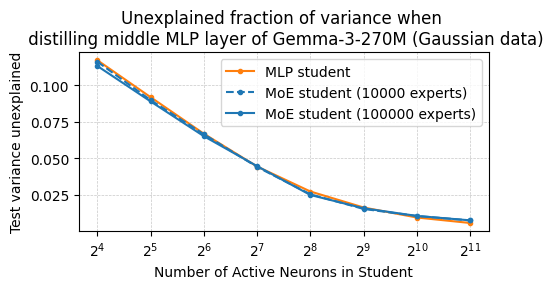

In [15]:
# heatmap for MLP plus MoE, single neuron
for model_name, layer_idx in [('EleutherAI/pythia-70m', 3), ('EleutherAI/pythia-410m', 12), ('EleutherAI/pythia-70m_gaussian', 3), ('EleutherAI/pythia-410m_gaussian', 12),
                              ('google/gemma-3-270m', 9), ('google/gemma-3-270m_gaussian', 9)]:
     
    
    plt.figure(figsize=(5,3))
    # Add the MLP baseline
    filtered_scores = {k: v for k, v in distill_scores.items() if k[0] == model_name and k[1] == layer_idx and k[2] == 'distillToMLP' if k[4] == 100}
    if not filtered_scores:
        print(f"No scores found for {model_name} layer {layer_idx} MLP")
        continue
    df = pd.DataFrame([
        {
            'batch_size': k[3],
            'num_epochs': k[4],
            'learning_rate': k[5],
            'hidden_dim': k[6],
            'validation_losses': v['validation_losses'],
            'output_variance' : v['output_variance'],
            'final_validation_loss' : v['validation_losses'][-1][-1],
            'final_normalized_mse' : v['validation_losses'][-1][-1] / v['output_variance']
        }
        for k, v in filtered_scores.items()
    ])

    active_neurons = []
    best_final_mses = []
    best_best_mses = []
    for logwidth in range(2,12):
        active_neurons.append(2**logwidth)
        curr_df = df[df['hidden_dim'] == 2**logwidth]
        if curr_df.empty:
            best_final_mses.append(None)
            best_best_mses.append(None)
            continue
        # if len(curr_df['final_normalized_mse']) > 1:
            # print(f"Multiple entries found for {model_name} layer {layer_idx}, hidden_dim {2**logwidth}")
            # print(curr_df)
        final_normalized_mse = curr_df['final_normalized_mse'].min()
        best_mse = (curr_df['validation_losses'].apply(lambda x: min(x[-1])) / curr_df['output_variance']).min()
        best_final_mses.append(final_normalized_mse)
        best_best_mses.append(best_mse)
    plt.plot(active_neurons, best_best_mses, marker='.', label=f'MLP student', color='tab:orange')


    # MoE with SN and projembd
    moe_color = 'tab:blue'
    # one linestyle per numexperts
    linestyles = ['--', '-']
    for num_experts_idx, num_experts in enumerate([10_000,100_000]):
        filtered_scores = {k: v for k, v in distill_scores.items() if k[0] == model_name and k[1] == layer_idx and k[2] == 'distillToMLPplusMoEsn_projembd' and k[3]['num_experts'] == num_experts}
        if not filtered_scores:
            print(f"No scores found for {model_name} layer {layer_idx} MoESN+projembd")
            continue

        def get_embd_name_from_key(k):
            return f"{k['shared_hidden_dim']} + {k['num_experts']}e_{k['granularity']}a_{k['expert_hidden_dim']}d_{k['key_proj_dim']}pkd"
        df = pd.DataFrame([
            {
                'batch_size': k[3]['batch_size'],
                'num_epochs': k[3]['num_epochs'],
                'learning_rate': k[3]['learning_rate'],
                'shared_hidden_dim': k[3]['shared_hidden_dim'],
                'num_experts': k[3]['num_experts'],
                'expert_hidden_dim': k[3]['expert_hidden_dim'],
                'validation_losses': v['validation_losses'],
                'normalized_validation_losses': [loss / v['output_variance'] for _, loss in v['validation_losses']],
                'output_variance' : v['output_variance'],
                'final_validation_loss' : v['validation_losses'][-1][-1],
                'final_normalized_mse' : v['validation_losses'][-1][-1] / v['output_variance'],
                'best_normalized_mse' : min([loss / v['output_variance'] for _, loss in v['validation_losses']]),
                'expert_arch' : get_embd_name_from_key(k[3]),
                'granularity' : k[3]['granularity'],
            }
            for k, v in filtered_scores.items()
        ])


        best_best_mses = []
        best_final_mses = []
        active_neurons = []

        for loggran in range(3,11):
            for shared_hidden_dim, granularity, expert_hidden_dim in [(2**loggran, 2**loggran, 1)]: # up to 500000 experts fit on one L40S for dim 1024
                curr_df = df[(df['shared_hidden_dim'] == shared_hidden_dim) &
                                (df['granularity'] == granularity) &
                                (df['expert_hidden_dim'] == expert_hidden_dim) & 
                                (df['num_epochs'] == 100) & 
                                (df['num_experts'] == num_experts)]
                if curr_df.empty:
                    best_best_mses.append(None)
                    best_final_mses.append(None)
                    active_neurons.append(shared_hidden_dim+granularity)
                    continue
                final_mses = []
                best_mses = []
                for learning_rate in (3e-4, 1e-4, 1e-3):
                        num_active = shared_hidden_dim+granularity
                        curr_lr_df = curr_df[curr_df['learning_rate'] == learning_rate]
                        if curr_lr_df.empty:
                            continue
                        if len(curr_lr_df['final_normalized_mse']) > 1:
                            print(f"Multiple entries found for {model_name} layer {layer_idx}, lr {learning_rate}, shd {shared_hidden_dim}, gran {granularity}, ehd {expert_hidden_dim}")
                            # print(curr_lr_df)
                        final_normalized_mse = curr_lr_df['final_normalized_mse'].values[0]
                        best_mse = curr_lr_df['best_normalized_mse'].values[0]
                        final_mses.append(final_normalized_mse)
                        best_mses.append(best_mse)
                best_final_mses.append(min(final_mses))
                best_best_mses.append(min(best_mses))
                active_neurons.append(shared_hidden_dim+granularity)
        plt.plot(active_neurons, best_best_mses, marker='.', label=f'MoE student ({num_experts} experts)', linestyle=linestyles[num_experts_idx], color=moe_color)

    model_name_to_title = {
        'google/gemma-3-270m' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Gemma-3-270M',
        'EleutherAI/pythia-70m' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-70M',
        'EleutherAI/pythia-410m' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-410M',
        'google/gemma-3-270m_gaussian' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Gemma-3-270M (Gaussian data)',
        'EleutherAI/pythia-70m_gaussian' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-70M (Gaussian data)',
        'EleutherAI/pythia-410m_gaussian' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-410M (Gaussian data)',
    }

    # print(best_best_mses)
    plt.title(model_name_to_title.get(model_name, f'Unexplained fraction of variance when distilling middle MLP layer of {model_name}'))
    plt.xscale('log', base=2)
    plt.ylabel('Test variance unexplained')
    plt.xlabel('Number of Active Neurons in Student')
    plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
    plt.legend()
    os.makedirs('plots', exist_ok=True)
    plt.tight_layout()
    plt.savefig(f'plots/distillation_moe_vs_mlp_{model_name.replace("/","_")}_layer{layer_idx}.pdf', bbox_inches='tight')
    plt.show()

## MoE with proj vs. MoE without proj

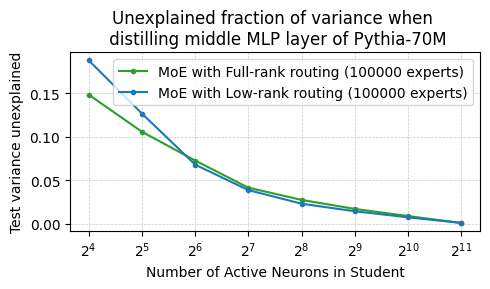

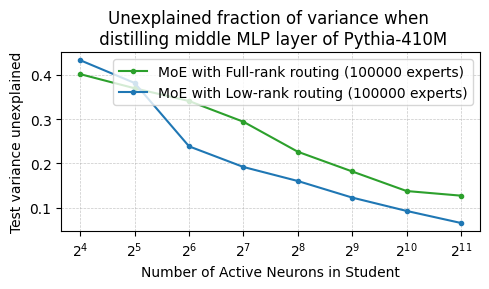

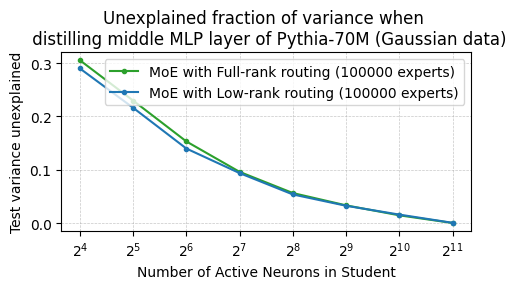

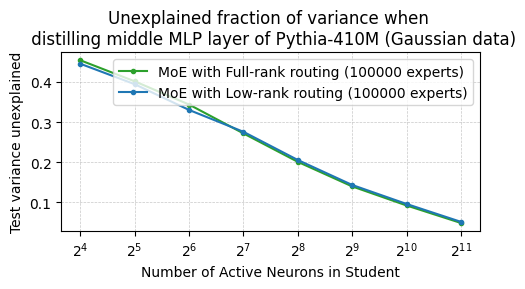

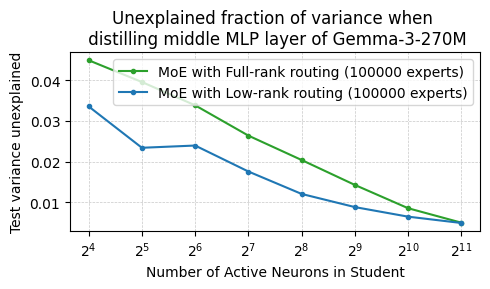

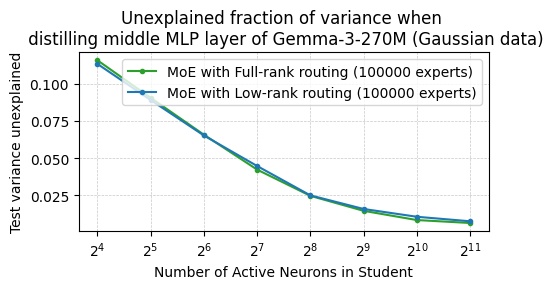

In [16]:
# heatmap for MLP plus MoE, single neuron
for model_name, layer_idx in [('EleutherAI/pythia-70m', 3), ('EleutherAI/pythia-410m', 12), ('EleutherAI/pythia-70m_gaussian', 3), ('EleutherAI/pythia-410m_gaussian', 12),
                              ('google/gemma-3-270m', 9), ('google/gemma-3-270m_gaussian', 9)]:
     

    plt.figure(figsize=(5,3))
    for num_experts in [100_000]:
        # MoE without projembd
        filtered_scores = {k: v for k, v in distill_scores.items() if k[0] == model_name and k[1] == layer_idx and k[2] == 'distillToMLPplusMoE_singleneuron' and k[3]['num_experts'] == num_experts}
        if not filtered_scores:
            print(f"No scores found for {model_name} layer {layer_idx} MoESN+projembd")
            continue

        def get_embd_name_from_key(k):
            return f"{k['shared_hidden_dim']} + {k['num_experts']}e_{k['granularity']}a_{k['expert_hidden_dim']}d"
        df = pd.DataFrame([
            {
                'batch_size': k[3]['batch_size'],
                'num_epochs': k[3]['num_epochs'],
                'learning_rate': k[3]['learning_rate'],
                'shared_hidden_dim': k[3]['shared_hidden_dim'],
                'num_experts': k[3]['num_experts'],
                'expert_hidden_dim': k[3]['expert_hidden_dim'],
                'validation_losses': v['validation_losses'],
                'normalized_validation_losses': [loss / v['output_variance'] for _, loss in v['validation_losses']],
                'output_variance' : v['output_variance'],
                'final_validation_loss' : v['validation_losses'][-1][-1],
                'final_normalized_mse' : v['validation_losses'][-1][-1] / v['output_variance'],
                'best_normalized_mse' : min([loss / v['output_variance'] for _, loss in v['validation_losses']]),
                'expert_arch' : get_embd_name_from_key(k[3]),
                'granularity' : k[3]['granularity'],
            }
            for k, v in filtered_scores.items()
        ])

        best_best_mses = []
        best_final_mses = []
        active_neurons = []
        for loggran in range(3,11):
            for shared_hidden_dim, granularity, expert_hidden_dim in [(2**loggran, 2**loggran, 1)]: # up to 500000 experts fit on one L40S for dim 1024
                curr_df = df[(df['shared_hidden_dim'] == shared_hidden_dim) &
                                (df['granularity'] == granularity) &
                                (df['expert_hidden_dim'] == expert_hidden_dim) & 
                                (df['num_epochs'] == 100) & 
                                (df['num_experts'] == num_experts)]
                if curr_df.empty:
                    best_best_mses.append(None)
                    best_final_mses.append(None)
                    active_neurons.append(shared_hidden_dim+granularity)
                    continue
                final_mses = []
                best_mses = []
                for learning_rate in (3e-4, 1e-4, 1e-3):
                        num_active = shared_hidden_dim+granularity
                        curr_lr_df = curr_df[curr_df['learning_rate'] == learning_rate]
                        if curr_lr_df.empty:
                            continue
                        if len(curr_lr_df['final_normalized_mse']) > 1:
                            print(f"Multiple entries found for {model_name} layer {layer_idx}, lr {learning_rate}, shd {shared_hidden_dim}, gran {granularity}, ehd {expert_hidden_dim}")
                            # print(curr_lr_df)
                        final_normalized_mse = curr_lr_df['final_normalized_mse'].values[0]
                        best_mse = curr_lr_df['best_normalized_mse'].values[0]
                        final_mses.append(final_normalized_mse)
                        best_mses.append(best_mse)
                best_final_mses.append(min(final_mses))
                best_best_mses.append(min(best_mses))
                active_neurons.append(shared_hidden_dim+granularity)
        plt.plot(active_neurons, best_best_mses, marker='.', label=f'MoE with Full-rank routing ({num_experts} experts)', color='tab:green')


    # MoE with SN and projembd

    moe_color = 'tab:blue'
    for num_experts in [100_000]:
        filtered_scores = {k: v for k, v in distill_scores.items() if k[0] == model_name and k[1] == layer_idx and k[2] == 'distillToMLPplusMoEsn_projembd'}
        if not filtered_scores:
            print(f"No scores found for {model_name} layer {layer_idx} MoESN+projembd")
            continue

        def get_embd_name_from_key(k):
            return f"{k['shared_hidden_dim']} + {k['num_experts']}e_{k['granularity']}a_{k['expert_hidden_dim']}d_{k['key_proj_dim']}pkd"
        df = pd.DataFrame([
            {
                'batch_size': k[3]['batch_size'],
                'num_epochs': k[3]['num_epochs'],
                'learning_rate': k[3]['learning_rate'],
                'shared_hidden_dim': k[3]['shared_hidden_dim'],
                'num_experts': k[3]['num_experts'],
                'expert_hidden_dim': k[3]['expert_hidden_dim'],
                'validation_losses': v['validation_losses'],
                'normalized_validation_losses': [loss / v['output_variance'] for _, loss in v['validation_losses']],
                'output_variance' : v['output_variance'],
                'final_validation_loss' : v['validation_losses'][-1][-1],
                'final_normalized_mse' : v['validation_losses'][-1][-1] / v['output_variance'],
                'best_normalized_mse' : min([loss / v['output_variance'] for _, loss in v['validation_losses']]),
                'expert_arch' : get_embd_name_from_key(k[3]),
                'granularity' : k[3]['granularity'],
            }
            for k, v in filtered_scores.items()
        ])


        best_best_mses = []
        best_final_mses = []
        active_neurons = []
        for loggran in range(3,11):
            for shared_hidden_dim, granularity, expert_hidden_dim in [(2**loggran, 2**loggran, 1)]: # up to 500000 experts fit on one L40S for dim 1024
                curr_df = df[(df['shared_hidden_dim'] == shared_hidden_dim) &
                                (df['granularity'] == granularity) &
                                (df['expert_hidden_dim'] == expert_hidden_dim) & 
                                (df['num_epochs'] == 100) & 
                                (df['num_experts'] == num_experts)]
                if curr_df.empty:
                    best_best_mses.append(None)
                    best_final_mses.append(None)
                    active_neurons.append(shared_hidden_dim+granularity)
                    continue
                final_mses = []
                best_mses = []
                for learning_rate in (3e-4, 1e-4, 1e-3):
                        num_active = shared_hidden_dim+granularity
                        curr_lr_df = curr_df[curr_df['learning_rate'] == learning_rate]
                        if curr_lr_df.empty:
                            continue
                        if len(curr_lr_df['final_normalized_mse']) > 1:
                            print(f"Multiple entries found for {model_name} layer {layer_idx}, lr {learning_rate}, shd {shared_hidden_dim}, gran {granularity}, ehd {expert_hidden_dim}")
                            # print(curr_lr_df)
                        final_normalized_mse = curr_lr_df['final_normalized_mse'].values[0]
                        best_mse = curr_lr_df['best_normalized_mse'].values[0]
                        final_mses.append(final_normalized_mse)
                        best_mses.append(best_mse)
                best_final_mses.append(min(final_mses))
                best_best_mses.append(min(best_mses))
                active_neurons.append(shared_hidden_dim+granularity)
        plt.plot(active_neurons, best_best_mses, marker='.', label=f'MoE with Low-rank routing ({num_experts} experts)', linestyle='-', color=moe_color)

    # print(best_best_mses)

    model_name_to_title = {
        'google/gemma-3-270m' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Gemma-3-270M',
        'EleutherAI/pythia-70m' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-70M',
        'EleutherAI/pythia-410m' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-410M',
        'google/gemma-3-270m_gaussian' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Gemma-3-270M (Gaussian data)',
        'EleutherAI/pythia-70m_gaussian' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-70M (Gaussian data)',
        'EleutherAI/pythia-410m_gaussian' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-410M (Gaussian data)',
    }
    plt.title(model_name_to_title.get(model_name, f'Unexplained fraction of variance when distilling middle MLP layer of {model_name}'))
    plt.xscale('log', base=2)
    plt.ylabel('Test variance unexplained')
    plt.xlabel('Number of Active Neurons in Student')
    plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'plots/distillation_moe_singleneuron_vs_moesnprojembd_{model_name.replace("/","_")}_layer{layer_idx}.pdf', bbox_inches='tight')
    plt.show()

# Test loss vs. training iteration

<Figure size 500x300 with 0 Axes>

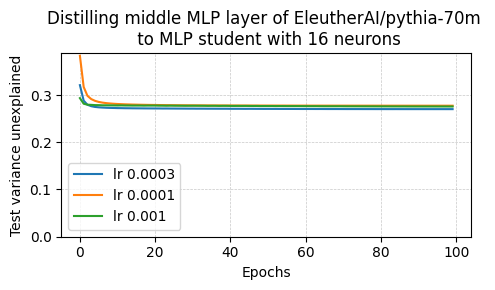

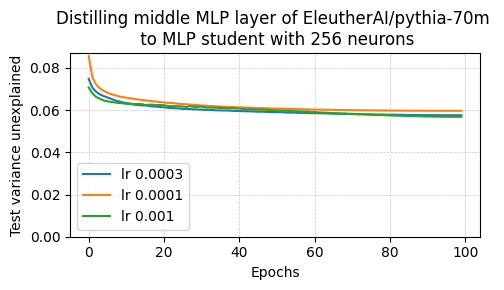

<Figure size 500x300 with 0 Axes>

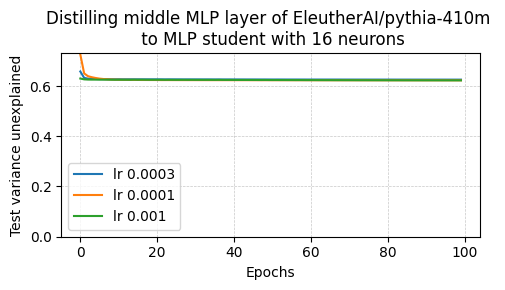

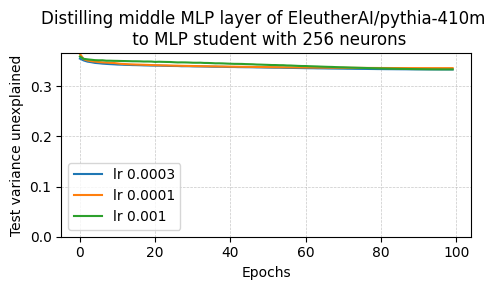

<Figure size 500x300 with 0 Axes>

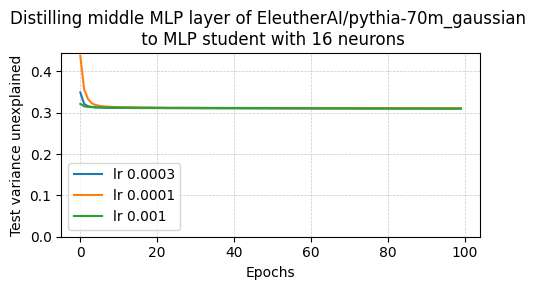

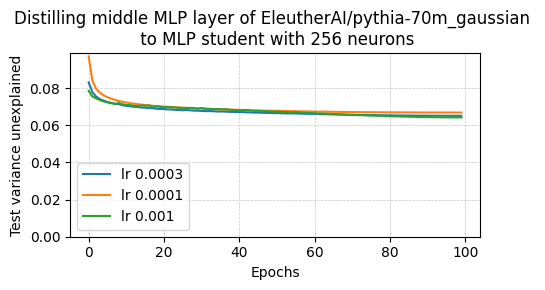

<Figure size 500x300 with 0 Axes>

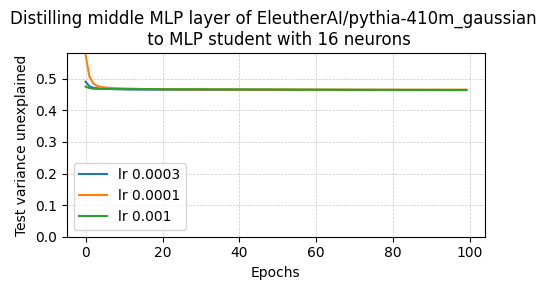

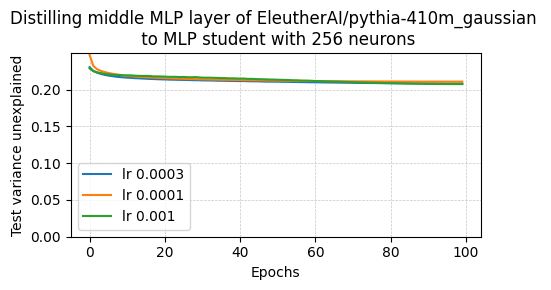

<Figure size 500x300 with 0 Axes>

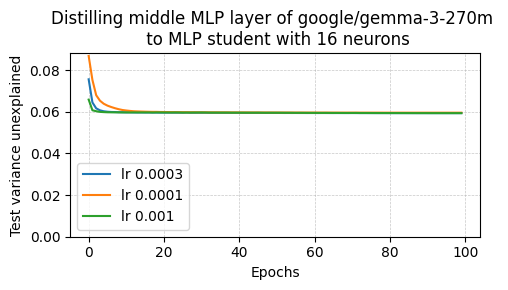

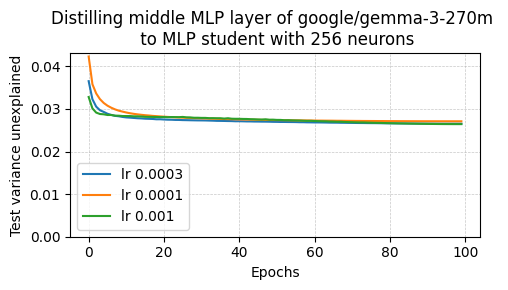

<Figure size 500x300 with 0 Axes>

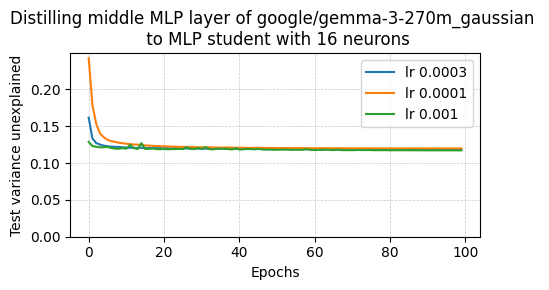

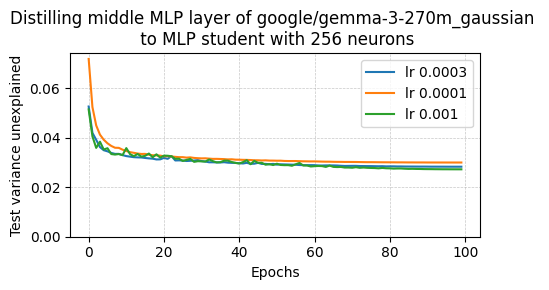

In [17]:
# heatmap for MLP plus MoE, single neuron
for model_name, layer_idx in [('EleutherAI/pythia-70m', 3), ('EleutherAI/pythia-410m', 12), ('EleutherAI/pythia-70m_gaussian', 3), ('EleutherAI/pythia-410m_gaussian', 12),
                              ('google/gemma-3-270m', 9), ('google/gemma-3-270m_gaussian', 9)]:
     
    
    plt.figure(figsize=(5,3))
    # Add the MLP baseline
    filtered_scores = {k: v for k, v in distill_scores.items() if k[0] == model_name and k[1] == layer_idx and k[2] == 'distillToMLP' if k[4] == 100}
    if not filtered_scores:
        print(f"No scores found for {model_name} layer {layer_idx} MLP")
        continue
    df = pd.DataFrame([
        {
            'batch_size': k[3],
            'num_epochs': k[4],
            'learning_rate': k[5],
            'hidden_dim': k[6],
            'validation_losses': v['validation_losses'],
            'normalized_validation_losses': [loss / v['output_variance'] for _, loss in v['validation_losses']],
            'output_variance' : v['output_variance'],
            'final_validation_loss' : v['validation_losses'][-1][-1],
            'final_normalized_mse' : v['validation_losses'][-1][-1] / v['output_variance']
        }
        for k, v in filtered_scores.items()
    ])


    for logwidth in range(2,12):
        if logwidth % 4 != 0:
            continue
        plt.figure(figsize=(5,3))
        active_neurons = 2**logwidth
        curr_df = df[df['hidden_dim'] == 2**logwidth]
        # print(curr_df)
        for learning_rate in (3e-4, 1e-4, 1e-3):
            curr_lr_df = curr_df[curr_df['learning_rate'] == learning_rate]
            if curr_lr_df.empty:
                continue
            if len(curr_lr_df['final_normalized_mse']) > 1:
                print(f"Multiple entries found for {model_name} layer {layer_idx}, hidden_dim {2**logwidth}, lr {learning_rate}")
                # print(curr_lr_df)
            plt.plot(curr_lr_df['normalized_validation_losses'].values[0], label=f'lr {learning_rate}')
        plt.xlabel('Epochs')
        plt.ylabel('Test variance unexplained')
        plt.title(f'Distilling middle MLP layer of {model_name} \n to MLP student with {active_neurons} neurons')
        plt.legend()
        plt.ylim(bottom=0)
        plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
        plt.tight_layout()
        plt.savefig(f'plots/distillation_mlp_learning_curve_{model_name.replace("/","_")}_layer{layer_idx}_hd{2**logwidth}.pdf', bbox_inches='tight')
        plt.show()

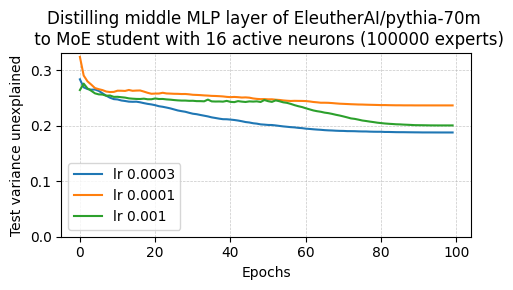

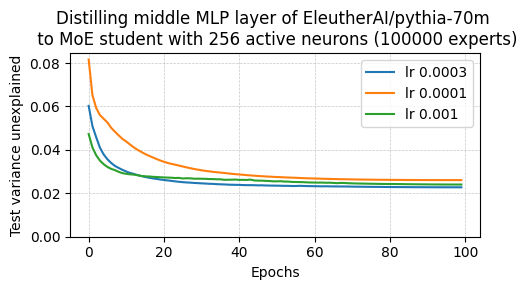

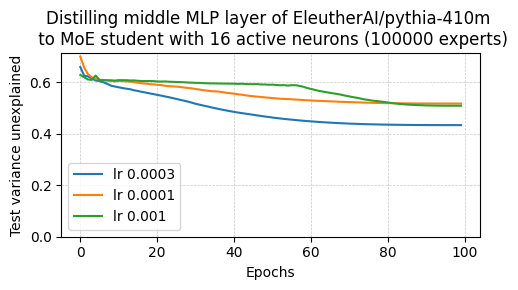

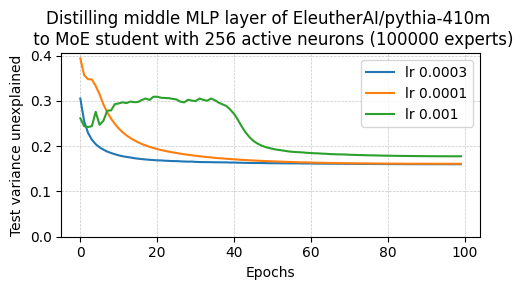

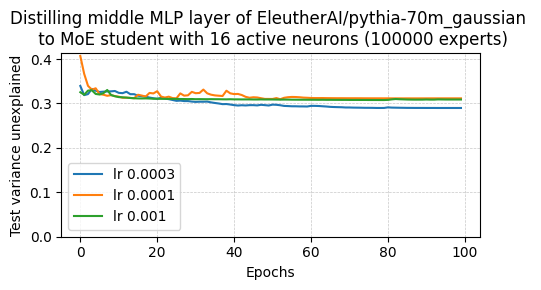

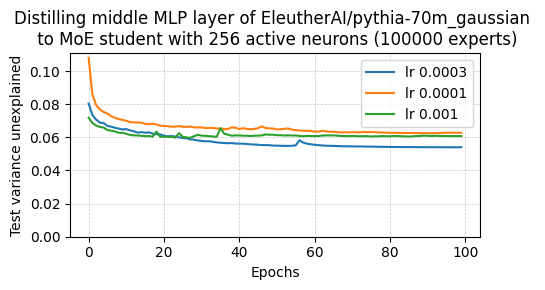

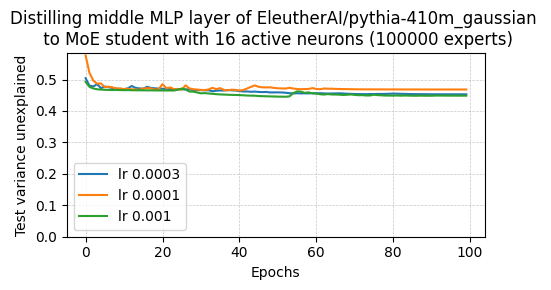

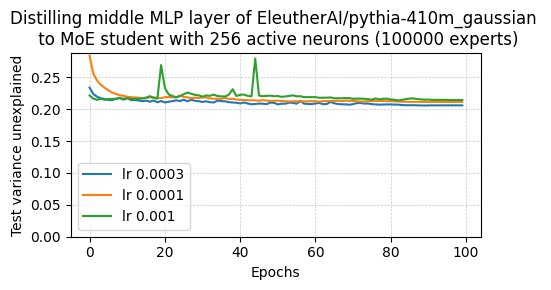

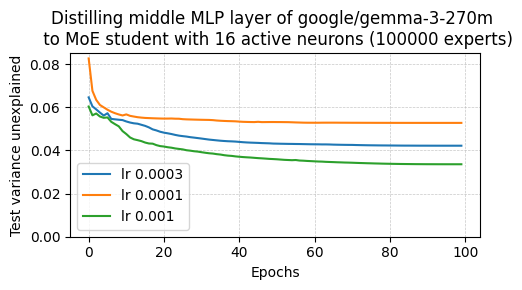

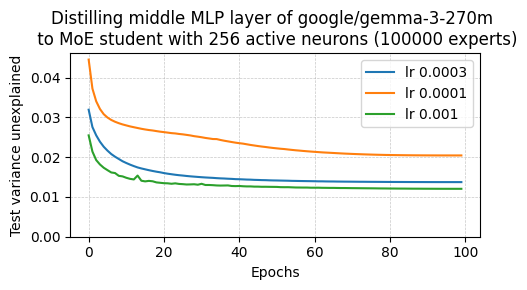

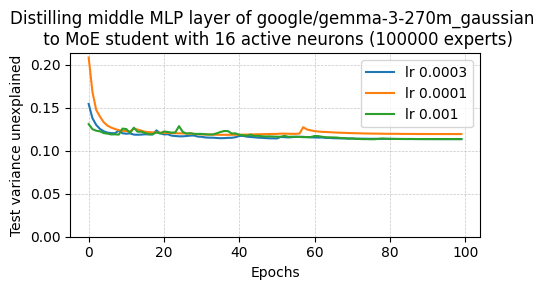

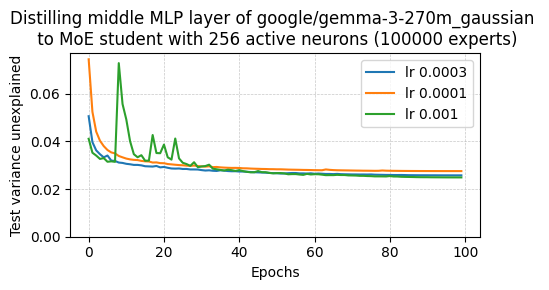

In [18]:
# heatmap for MLP plus MoE, single neuron
for model_name, layer_idx in [('EleutherAI/pythia-70m', 3), ('EleutherAI/pythia-410m', 12), ('EleutherAI/pythia-70m_gaussian', 3), ('EleutherAI/pythia-410m_gaussian', 12),
                              ('google/gemma-3-270m', 9), ('google/gemma-3-270m_gaussian', 9)]:
     

    # MoE with SN and projembd
    for num_experts in [100000]:
        filtered_scores = {k: v for k, v in distill_scores.items() if k[0] == model_name and k[1] == layer_idx and k[2] == 'distillToMLPplusMoEsn_projembd' and k[3]['num_experts'] == num_experts}
        if not filtered_scores:
            print(f"No scores found for {model_name} layer {layer_idx} MoESN+projembd")
            continue

        def get_embd_name_from_key(k):
            return f"{k['shared_hidden_dim']} + {k['num_experts']}e_{k['granularity']}a_{k['expert_hidden_dim']}d_{k['key_proj_dim']}pkd"
        df = pd.DataFrame([
            {
                'batch_size': k[3]['batch_size'],
                'num_epochs': k[3]['num_epochs'],
                'learning_rate': k[3]['learning_rate'],
                'shared_hidden_dim': k[3]['shared_hidden_dim'],
                'num_experts': k[3]['num_experts'],
                'expert_hidden_dim': k[3]['expert_hidden_dim'],
                'validation_losses': v['validation_losses'],
                'normalized_validation_losses': [loss / v['output_variance'] for _, loss in v['validation_losses']],
                'output_variance' : v['output_variance'],
                'final_validation_loss' : v['validation_losses'][-1][-1],
                'final_normalized_mse' : v['validation_losses'][-1][-1] / v['output_variance'],
                'best_normalized_mse' : min([loss / v['output_variance'] for _, loss in v['validation_losses']]),
                'expert_arch' : get_embd_name_from_key(k[3]),
                'granularity' : k[3]['granularity'],
            }
            for k, v in filtered_scores.items()
        ])

        for loggran in range(3,11):
            if (loggran+1) % 4 != 0:
                continue
            plt.figure(figsize=(5,3))
            for shared_hidden_dim, granularity, expert_hidden_dim in [(2**loggran, 2**loggran, 1)]: # up to 500000 experts fit on one L40S for dim 1024
                curr_df = df[(df['shared_hidden_dim'] == shared_hidden_dim) &
                                (df['granularity'] == granularity) &
                                (df['expert_hidden_dim'] == expert_hidden_dim) & 
                                (df['num_epochs'] == 100) & 
                                (df['num_experts'] == num_experts)]
                if curr_df.empty:
                    best_best_mses.append(None)
                    best_final_mses.append(None)
                    active_neurons.append(shared_hidden_dim+granularity)
                    continue
                final_mses = []
                best_mses = []
                for learning_rate in (3e-4, 1e-4, 1e-3):
                    curr_lr_df = curr_df[curr_df['learning_rate'] == learning_rate]
                    if curr_lr_df.empty:
                        continue
                    if len(curr_lr_df['final_normalized_mse']) > 1:
                        print(f"Multiple entries found for {model_name} layer {layer_idx}, hidden_dim {2**logwidth}, lr {learning_rate}")
                        # print(curr_lr_df)
                    plt.plot(curr_lr_df['normalized_validation_losses'].values[0], label=f'lr {learning_rate}')
            plt.legend()
            plt.title(f'Distilling middle MLP layer of {model_name} \n to MoE student with {shared_hidden_dim+granularity} active neurons ({num_experts} experts)')
            plt.xlabel('Epochs')
            plt.ylabel('Test variance unexplained')
            plt.ylim(bottom=0)
            plt.tight_layout()
            plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
            plt.savefig(f'plots/distillation_moe_projembd_learningcurves_{model_name.replace("/","_")}_lr{learning_rate}_{shared_hidden_dim+granularity}.pdf', bbox_inches='tight')
            plt.show()
                        

    # model_name_to_title = {
    #     'google/gemma-3-270m' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Gemma-3-270M',
    #     'EleutherAI/pythia-70m' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-70M',
    #     'EleutherAI/pythia-410m' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-410M',
    #     'google/gemma-3-270m_gaussian' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Gemma-3-270M (Gaussian data)',
    #     'EleutherAI/pythia-70m_gaussian' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-70M (Gaussian data)',
    #     'EleutherAI/pythia-410m_gaussian' : 'Unexplained fraction of variance when \n distilling middle MLP layer of Pythia-410M (Gaussian data)',
    # }

    # # print(best_best_mses)
    # plt.title(model_name_to_title.get(model_name, f'Unexplained fraction of variance when distilling middle MLP layer of {model_name}'))
    # plt.xscale('log', base=2)
    # plt.ylabel('Test variance unexplained')
    # plt.xlabel('Number of Active Neurons in Student')
    # plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
    # plt.legend()
    # os.makedirs('plots', exist_ok=True)
    # plt.tight_layout()
    # plt.savefig(f'plots/distillation_moe_vs_mlp_{model_name.replace("/","_")}_layer{layer_idx}.pdf', bbox_inches='tight')
    plt.show()